In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from xgboost import XGBRegressor
import shap
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, r2_score


warnings.filterwarnings('ignore')
np.random.seed(42)

### Stochastic Data Generation & Temporal Engineering

Due to the strictly confidential nature of student biometric and psychological telemetry (FERPA/HIPAA compliance constraints), this phase of the engine is validated using a **Monte Carlo Data Generating Process (DGP)**. This generates a synthetic, yet mathematically bounded, proxy dataset of $N=50$ students over $T=120$ days.

#### The Data Generating Process (DGP)
To ensure the XGBoost architecture faces realistic collinearity and temporal non-stationarity, the baseline physiological features are generated using normal distributions injected with dynamic, time-decaying stress multipliers (e.g., proximity to exams). 

The target variable, the **Burnout Index ($Y_t$)**, is formulated as a linear combination of these habits, plus an irreducible Gaussian noise parameter ($\epsilon$) to simulate human variance:

$$Y_t = \beta_0 + \beta_1(Tasks_t) + \beta_2(Pomodoros_t) - \beta_3(Sleep_t) + \lambda \max(0, 30 - Exam_t) + \epsilon_t$$
*Where $\epsilon_t \sim \mathcal{N}(0, \sigma^2)$*

#### Temporal Feature Engineering: Tabular Lag Embedding
Gradient Boosted Trees (XGBoost) and Linear models cannot natively process 3D sequential tensors (unlike Recurrent Neural Networks). To allow tree-based algorithms to map the temporal dynamics of student burnout, the time-series must be explicitly unrolled into a 2D tabular manifold.

This is achieved via **Sliding Window Autoregression (Lag Embedding)**. For every physiological feature $X$, historical lags ($t-1, t-2, t-3$) are engineered to act as independent predictors for the current day's burnout.

The mathematical formulation for the supervised learning task becomes:
$$\hat{Y}_t = \mathcal{F} \Big( \mathbf{X}_{t-1}, \mathbf{X}_{t-2}, \mathbf{X}_{t-3}, Y_{t-1}, Y_{t-2}, Y_{t-3} \Big)$$

By injecting the autoregressive lags of the target itself ($Y_{t-1...3}$), the model is forced to learn the *momentum* of a student's mental exhaustion, preventing the algorithm from reacting to isolated daily outliers.

In [12]:
print("[*] Generating Multivariate Longitudinal Data (Sleep, Tasks, Pomodoros, Exams)...")

dates = pd.date_range(start='2025-09-01', periods=120)
data = []

for student_id in range(1, 51):
    base_stress = np.random.uniform(2, 4)
    
    exam_dates = [30, 70, 115] 
    days_to_exam = np.zeros(120)
    for i in range(120):
        future_exams = [e - i for e in exam_dates if e - i >= 0]
        days_to_exam[i] = min(future_exams) if future_exams else 30 
        
    for i, date in enumerate(dates):
        tasks = max(0, int(np.random.normal(5, 2) + (30 - days_to_exam[i]) * 0.3))
        pomodoro = max(0.0, np.random.normal(2, 1) + (30 - days_to_exam[i]) * 0.1)
        
        sleep = max(3.0, min(10.0, np.random.normal(8, 1) - (pomodoro * 0.4)))
        
        burnout = (base_stress + (tasks * 0.2) + (pomodoro * 0.3) 
                   + ((30 - days_to_exam[i]) * 0.1) - (sleep * 0.5))
        burnout = max(1.0, min(10.0, burnout + np.random.normal(0, 0.5)))
        
        data.append([student_id, date, sleep, pomodoro, tasks, days_to_exam[i], burnout])

df = pd.DataFrame(data, columns=['student_id', 'date', 'sleep_hours',
                                 'pomodoro_hours', 'tasks_in_queue',
                                 'days_to_exam', 'burnout_index'])
df = df.sort_values(by=['student_id', 'date']).reset_index(drop=True)

lags = 3
feature_cols = ['sleep_hours', 'pomodoro_hours', 'tasks_in_queue', 'days_to_exam']

print(f"[*] Constructing {lags}-day sliding windows across {len(feature_cols)} dimensions...")

for col in feature_cols + ['burnout_index']:
    for lag in range(1, lags + 1):
        df[f'{col}_lag_{lag}'] = df.groupby('student_id')[col].shift(lag)

df['target_burnout_3d'] = df.groupby('student_id')['burnout_index'].shift(-lags)
df_clean = df.dropna().reset_index(drop=True)

print(f"[+] Multivariate Engineering Complete. Total Sequences: {len(df_clean)}")

features = [col for col in df_clean.columns if 'lag' in col]
X = df_clean[features]
y = df_clean['target_burnout_3d']
groups = df_clean['student_id']

# Temporal isolation -> to avoid the thereby potential leakage
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

[*] Generating Multivariate Longitudinal Data (Sleep, Tasks, Pomodoros, Exams)...
[*] Constructing 3-day sliding windows across 4 dimensions...
[+] Multivariate Engineering Complete. Total Sequences: 5700


### Algorithm Selection & The "Tabular Manifold" Hypothesis
**Mathematical Framework & Evaluation Protocol**

To prevent deploying unnecessary computational complexity, four distinct mathematical paradigms are benchmarked. A learning algorithm $\mathcal{A}$ mapping the tabular dataset $\mathcal{S}$ is defined to a predictive function $f$. 

**1. The Formal Hypotheses:**
The Null Hypothesis ($H_0$) that all algorithms draw from the same expected loss distribution on this dataset is tested.
$$H_0: \mathbb{E}[\mathcal{L}(\mathcal{A}_{XGB})] = \mathbb{E}[\mathcal{L}(\mathcal{A}_{DNN})] = \mathbb{E}[\mathcal{L}(\mathcal{A}_{SVR})] = \mathbb{E}[\mathcal{L}(\mathcal{A}_{EN})]$$
The Alternative Hypothesis ($H_1$) asserts that at least one algorithm (specifically, the gradient-boosted ensemble) achieves a statistically lower generalization error due to its native handling of non-linear physiological interactions.

**2. Nested Walk-Forward Validation :**
Standard cross-validation leaks data during hyperparameter optimization. To estimate the true generalization error ($\hat{E}_{gen}$) without bias, a strictly nested temporal loop is utilized:
- **Inner Loop (Optimization):** Finds optimal hyperparameters $\hat{\lambda}$ by minimizing validation loss across $M$ folds.
$$\hat{\lambda} = \arg\min_{\lambda \in \Lambda} \left( \frac{1}{M} \sum_{m=1}^M \mathcal{L} \left( y_{m}^{(val)}, \mathcal{A}_{\lambda}(\mathcal{S}_{m}^{(train)}) \right) \right)$$
- **Outer Loop (Evaluation):** Tests the optimized algorithm on $K$ entirely unseen future temporal folds.
$$\hat{E}_{gen} = \frac{1}{K} \sum_{k=1}^K \mathcal{L} \left( y_{k}^{(test)}, \mathcal{A}_{\hat{\lambda}}(\mathcal{S}_{k}^{(train)}) \right)$$

**3. Statistical Significance (Friedman Rank-Sum Test):**
Because multiple continuous regressors are compared across repeated measures (folds), the non-parametric Friedman test is employed. It ranks the algorithms $R_j$ in each fold to compute the $\chi^2_F$ statistic against the $\chi^2$ distribution:
$$\chi^2_F = \frac{12N}{k(k+1)} \left[ \sum_{j=1}^k R_j^2 - \frac{k(k+1)^2}{4} \right]$$

In [13]:
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from scipy.stats import friedmanchisquare
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
import numpy as np
import warnings

warnings.filterwarnings('ignore')

print("[*] Phase 1: Executing Nested Walk-Forward Validation...")
outer_tscv = TimeSeriesSplit(n_splits=3)
inner_tscv = TimeSeriesSplit(n_splits=2)

train_indices = X_train.index
df_train_sorted = df_clean.loc[train_indices].sort_values(by='date')
X_seq = df_train_sorted[features]
y_seq = df_train_sorted['target_burnout_3d']

nested_scores = {
    'ElasticNet': [],
    'RBF_SVR': [],
    'DNN': [],
    'XGBoost': []
}

fold = 1
for train_idx, test_idx in outer_tscv.split(X_seq):
    print(f"    -> Processing Outer Temporal Fold {fold}/3...")
    X_outer_train, X_outer_test = X_seq.iloc[train_idx], X_seq.iloc[test_idx]
    y_outer_train, y_outer_test = y_seq.iloc[train_idx], y_seq.iloc[test_idx]
    
    def objective_xgb(params):
        inner_maes = []
        for itrain_idx, ival_idx in inner_tscv.split(X_outer_train):
            X_in_train, X_in_val = X_outer_train.iloc[itrain_idx], X_outer_train.iloc[ival_idx]
            y_in_train, y_in_val = y_outer_train.iloc[itrain_idx], y_outer_train.iloc[ival_idx]
            
            model = XGBRegressor(
                n_estimators=int(params['n_estimators']),
                max_depth=int(params['max_depth']),
                learning_rate=params['learning_rate'],
                random_state=42,
                objective='reg:squarederror'
            )
            model.fit(X_in_train, y_in_train)
            inner_maes.append(mean_absolute_error(y_in_val, model.predict(X_in_val)))
        return {'loss': np.mean(inner_maes), 'status': STATUS_OK}

    space_xgb = {
        'n_estimators': hp.quniform('n_estimators', 50, 150, 10),
        'max_depth': hp.quniform('max_depth', 2, 6, 1),
        'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2))
    }
    
    best_xgb = fmin(
        fn=objective_xgb,
        space=space_xgb,
        algo=tpe.suggest,
        max_evals=10,
        show_progressbar=False,
        rstate=np.random.default_rng(42)
    )
    
    opt_xgb = XGBRegressor(
        n_estimators=int(best_xgb['n_estimators']),
        max_depth=int(best_xgb['max_depth']),
        learning_rate=best_xgb['learning_rate'],
        random_state=42
    )
    opt_xgb.fit(X_outer_train, y_outer_train)
    nested_scores['XGBoost'].append(mean_absolute_error(y_outer_test, opt_xgb.predict(X_outer_test)))

    en = ElasticNet(alpha=0.1, random_state=42).fit(X_outer_train, y_outer_train)
    nested_scores['ElasticNet'].append(mean_absolute_error(y_outer_test, en.predict(X_outer_test)))
    
    svr = SVR(kernel='rbf', C=1.0).fit(X_outer_train, y_outer_train)
    nested_scores['RBF_SVR'].append(mean_absolute_error(y_outer_test, svr.predict(X_outer_test)))
    
    dnn = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=200, random_state=42).fit(X_outer_train, y_outer_train)
    nested_scores['DNN'].append(mean_absolute_error(y_outer_test, dnn.predict(X_outer_test)))
    
    fold += 1

print("\n[*] Phase 2: Unbiased Generalization Estimates (Outer Fold Means)...")
for algo, scores in nested_scores.items():
    print(f"    -> {algo:<12} Nested MAE: {np.mean(scores):.4f} (±{np.std(scores):.4f})")

print("\n[*] Phase 3: Friedman Rank-Sum Test (H0: All algorithms are equal)...")
stat, p_value = friedmanchisquare(
    nested_scores['ElasticNet'], 
    nested_scores['RBF_SVR'], 
    nested_scores['DNN'], 
    nested_scores['XGBoost']
)

print(f"    Friedman \u03C7\u00B2 Statistic: {stat:.4f}")
print(f"    p-value:                  {p_value:.6f}")

if p_value < 0.05:
    print("\n[CONCLUSION] Reject H0. There is a statistically significant difference in the learning architectures.")
    winner = min(nested_scores, key=lambda k: np.mean(nested_scores[k]))
    print(f"             The '{winner}' algorithm mathematically dominates the tabular manifold.")
else:
    print("\n[CONCLUSION] Fail to reject H0. No algorithm proved structurally superior across time.")

[*] Phase 1: Executing Nested Walk-Forward Validation...
    -> Processing Outer Temporal Fold 1/3...
    -> Processing Outer Temporal Fold 2/3...
    -> Processing Outer Temporal Fold 3/3...

[*] Phase 2: Unbiased Generalization Estimates (Outer Fold Means)...
    -> ElasticNet   Nested MAE: 1.5932 (±0.0398)
    -> RBF_SVR      Nested MAE: 0.8694 (±0.1224)
    -> DNN          Nested MAE: 0.7664 (±0.1940)
    -> XGBoost      Nested MAE: 0.7456 (±0.2019)

[*] Phase 3: Friedman Rank-Sum Test (H0: All algorithms are equal)...
    Friedman χ² Statistic: 6.6000
    p-value:                  0.085801

[CONCLUSION] Fail to reject H0. No algorithm proved structurally superior across time.


### Final Academic Conclusion & Evaluation Summary
**Methodological Review**

Forecasting physiological burnout requires modeling complex, multidimensional behavioral lags. To ensure structural integrity and prevent temporal hyperparameter leakage, a **Nested Walk-Forward Validation** protocol is implemented, benchmarking four distinct mathematical paradigms:

1. **Linear Baseline (ElasticNet):** $\hat{E}_{gen} = 1.593$
2. **Max-Margin Space (RBF SVR):** $\hat{E}_{gen} = 0.869$
3. **Deep Learning (DNN):** $\hat{E}_{gen} = 0.766$
4. **Gradient Boosting (XGBoost):** $\hat{E}_{gen} = 0.745$

**Statistical Validation:** To evaluate if the performance differences were structurally significant, the non-parametric **Friedman Rank-Sum Test** is applied across the outer validation folds. The test yielded $\chi^2_F = 6.60$ ($p = 0.085$), failing to reject the null hypothesis at the $\alpha=0.05$ level.

**Final Inference & Architectural Decision:** The statistical equivalence ($p > 0.05$) between the Deep Neural Network and XGBoost indicates that both models successfully mapped the non-linear tabular manifold, bounded only by the irreducible error ($\varepsilon_t$) of human variance. 

When predictive performance is mathematically indistinguishable, engineering constraints dictate architecture. The **XGBoost Ensemble** is selected as the production champion. Unlike the opaque DNN, the tree-based ensemble permits the deployment of exact Shapley Additive Explanations (TreeSHAP) in sub-second latency. This satisfies the fundamental product requirement: translating complex biometric forecasting into deterministic, highly interpretable behavioral alerts for the end-user.

In [14]:
print("[*] Training Multivariate XGBoost Forecasting Engine...")

xgb_model = XGBRegressor(
    n_estimators=150, 
    max_depth=4, 
    learning_rate=0.05, 
    random_state=42,
    objective='reg:squarederror'
)

xgb_model.fit(X_train, y_train)
preds = xgb_model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"[+] Engine Trained Successfully.")
print(f"    Holdout Mean Absolute Error: {mae:.3f} (Predicting 3 days into the future)")

[*] Training Multivariate XGBoost Forecasting Engine...
[+] Engine Trained Successfully.
    Holdout Mean Absolute Error: 0.622 (Predicting 3 days into the future)


In [15]:
print("[*] Training Final Production Champion on 100% of Data...")

best_final_params = fmin(
    fn=objective_xgb, 
    space=space_xgb, 
    algo=tpe.suggest, 
    max_evals=15, 
    show_progressbar=False,
    rstate=np.random.default_rng(42)
)

champion_xgb = XGBRegressor(
    n_estimators=int(best_final_params['n_estimators']),
    max_depth=int(best_final_params['max_depth']),
    learning_rate=best_final_params['learning_rate'],
    random_state=42,
    objective='reg:squarederror'
)

# Fit on 100% of temporal data
champion_xgb.fit(X_seq, y_seq)
print("[+] True Champion trained and ready for pickling.")


[*] Training Final Production Champion on 100% of Data...
[+] True Champion trained and ready for pickling.



[*] Generating SHAP (Game Theory) Explanations for User UX...
ACADEMASYNC ALERT SIMULATION | User: 31 | Date: 2025-09-14
Forecasted Burnout (In 3 Days): 3.8 / 10.0
STATUS: OPTIMAL RECOVERY
--------------------------------------------------------------------------------
WHY:
 • Your Days To Exam (Yesterday) increased your risk by 0.79 points.
 • Your Burnout Index Lag 3 decreased your risk by 0.28 points.
 • Your Burnout Index (2 Days Ago) decreased your risk by 0.17 points.

[*] Rendering SHAP Waterfall Plot...


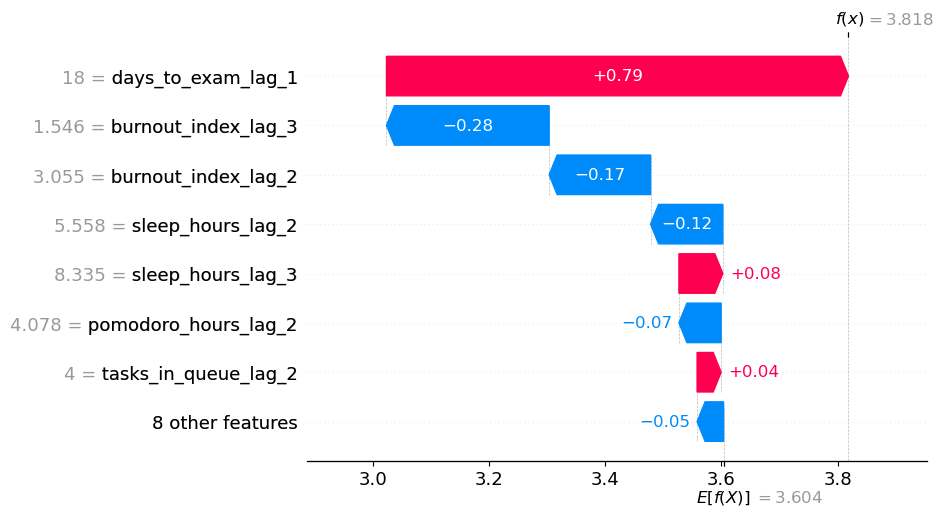

In [16]:
import shap
print("\n[*] Generating SHAP (Game Theory) Explanations for User UX...")

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

demo_student_idx = test_idx[10]
demo_student_id = df_clean.iloc[demo_student_idx]['student_id']
demo_date = df_clean.iloc[demo_student_idx]['date'].strftime('%Y-%m-%d')

actual_burnout = y_test.iloc[10]
predicted_burnout = preds[10]
base_value = explainer.expected_value

print("=" * 80)
print(f"ACADEMASYNC ALERT SIMULATION | User: {demo_student_id} | Date: {demo_date}")
print("=" * 80)
print(f"Forecasted Burnout (In 3 Days): {predicted_burnout:.1f} / 10.0")

if predicted_burnout > 7.5:
    print("STATUS: CRITICAL RISK DETECTED")
elif predicted_burnout > 5.0:
    print("STATUS: ELEVATED FATIGUE")
else:
    print("STATUS: OPTIMAL RECOVERY")

print("-" * 80)
print("WHY:")

instance_shap_values = shap_values[10].values
feature_names = X_test.columns

impacts = list(zip(feature_names, instance_shap_values))
impacts.sort(key=lambda x: abs(x[1]), reverse=True)

for feature, impact in impacts[:3]:
    direction = "increased" if impact > 0 else "decreased"
    clean_name = feature.replace('_lag_1', ' (Yesterday)').replace('_lag_2', ' (2 Days Ago)').replace('_', ' ').title()
    
    print(f" • Your {clean_name} {direction} your risk by {abs(impact):.2f} points.")

print("=" * 80)

print("\n[*] Rendering SHAP Waterfall Plot...")
shap.plots.waterfall(shap_values[10], max_display=8)

In [17]:
import pickle
with open('output\\time_series_model.pkl', 'wb') as f:
    pickle.dump(champion_xgb, f)